# Stanbic Bank Ghana — SME Credit Assessment
## Notebook 01: Setup & Exploratory Data Analysis

**Purpose:** Mount Google Drive, install dependencies, load raw data, and answer 6 specific EDA questions that drive every subsequent modeling decision.

**Key principle:** EDA is not about generating every possible chart. It is about answering specific questions *before* modeling. Each question below has a direct impact on a downstream decision.

| Question | Why it matters |
|----------|----------------|
| 1. Class distribution | Determines class imbalance strategy, makes accuracy useless as metric |
| 2. Missing data pattern | Determines imputation strategy per column |
| 3. Numeric distributions | Detects skew → need for log transformation (Logistic Regression) |
| 4. Default rate by group | Fairness baseline BEFORE model runs |
| 5. Correlation with target | Validates feature engineering choices |
| 6. Multicollinearity | Detects problematic feature pairs for Logistic Regression |

## 0. Environment Setup

**Why mount Google Drive:** Colab sessions terminate after ~90 minutes of inactivity. All data, models, and outputs are saved to Drive so nothing is lost between sessions.

**Why `sys.path.insert(0, ...)`:** Python searches directories in `sys.path` order. Inserting our `src/` directory at index 0 (highest priority) allows `from preprocessing import clean_application` without complex relative imports — mimics installing a local package.

In [1]:
# ── CELL 1: Mount Drive and configure paths ──────────────────────────────────
import sys
import os

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/stanbic_sme_credit'
except ImportError:
    IN_COLAB = False
    _search = os.getcwd()
    BASE_PATH = _search
    for _ in range(3):
        if os.path.isdir(os.path.join(BASE_PATH, 'src')):
            break
        BASE_PATH = os.path.dirname(BASE_PATH)

sys.path.insert(0, os.path.join(BASE_PATH, 'src'))
env_str = 'Google Colab' if IN_COLAB else 'Local Jupyter'
print(f'Environment : {env_str}')
print(f'Base path   : {BASE_PATH}')

Mounted at /content/drive
Environment : Google Colab
Base path   : /content/drive/MyDrive/stanbic_sme_credit


In [2]:
# ── CELL 2: Install extra dependencies ───────────────────────────────────────
# WHY these packages:
#   xgboost        - gradient boosting (Model 2)
#   lightgbm       - fast gradient boosting (comparison if needed)
#   imbalanced-learn - SMOTE for class imbalance comparison
#   shap           - SHapley Additive exPlanations for model explainability
#   statsmodels    - VIF calculation for multicollinearity check
# All are pre-installed in Colab; this ensures latest versions.

!pip install -q xgboost lightgbm imbalanced-learn shap statsmodels
print('Dependencies ready.')

Dependencies ready.


In [3]:
# ── CELL 3: Create Google Drive directory structure ───────────────────────────
# WHY create now: Drive directories persist between sessions.
# data/raw/ is SACRED — never overwrite the original file.
# data/interim/ holds cleaned-but-not-split data (reproducible re-splitting).
# src/ holds reusable Python modules callable from any notebook.

DIRS = [
    'data/raw',
    'data/interim',
    'data/processed',
    'models',
    'notebooks',
    'reports/figures',
    'src'
]

for d in DIRS:
    path = f'{BASE_PATH}/{d}'
    os.makedirs(path, exist_ok=True)
    print(f'  OK  {path}')

print('\nDirectory structure ready.')

  OK  /content/drive/MyDrive/stanbic_sme_credit/data/raw
  OK  /content/drive/MyDrive/stanbic_sme_credit/data/interim
  OK  /content/drive/MyDrive/stanbic_sme_credit/data/processed
  OK  /content/drive/MyDrive/stanbic_sme_credit/models
  OK  /content/drive/MyDrive/stanbic_sme_credit/notebooks
  OK  /content/drive/MyDrive/stanbic_sme_credit/reports/figures
  OK  /content/drive/MyDrive/stanbic_sme_credit/src

Directory structure ready.


In [4]:
# ── CELL 4: Core imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGURES_PATH = f'{BASE_PATH}/reports/figures'

print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

**IMPORTANT:** We ONLY read from `data/raw/`. We never write back to it. If the original file is corrupted, the entire project is unrecoverable.

In [5]:
# ── CELL 5: Load and inspect raw data ─────────────────────────────────────────
# Upload the CSV to data/raw/ manually via the Drive UI before running this cell.
RAW_PATH = f'{BASE_PATH}/data/raw/ds-sme_loan_applications_stanbic_gh.csv'

df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f'Shape: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
print(f'Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Column dtypes:')
print(df_raw.dtypes.to_string())

Shape: 3,037 rows  x  29 columns
Memory usage: 2972.2 KB

Column dtypes:
application_id                   object
business_name                    object
sector                           object
region                           object
ethnic_group                     object
years_in_operation              float64
owner_gender                     object
owner_age                         int64
disability_status                object
num_employees                     int64
annual_revenue_ghs               object
monthly_momo_volume_ghs         float64
avg_monthly_bank_balance_ghs    float64
bank_account_tenure_months        int64
has_momo_account                 object
gra_tin                          object
loan_amount_requested_ghs       float64
loan_purpose                     object
collateral_type                  object
collateral_value_ghs            float64
previous_loan_count               int64
previous_default                 object
credit_bureau_score             float64
rm_reco

In [6]:
# ── CELL 6: First look at the data ────────────────────────────────────────────
# Work on a copy — never mutate df_raw in this notebook (read-only)
df = df_raw.copy()
df.head()

,application_id,business_name,sector,region,ethnic_group,years_in_operation,owner_gender,owner_age,disability_status,num_employees,annual_revenue_ghs,monthly_momo_volume_ghs,avg_monthly_bank_balance_ghs,bank_account_tenure_months,has_momo_account,gra_tin,loan_amount_requested_ghs,loan_purpose,collateral_type,collateral_value_ghs,previous_loan_count,previous_default,credit_bureau_score,rm_recommendation,internal_risk_grade,application_date,contact_phone,days_past_due_current,loan_default
0,SBG-2025-01722,Achimota Farms,Fishing,Ashanti,Akan,0.6000,Female,34,No,2,11218.55,NaN,1009.8500,9,yes,P004187922,11131.4700,Business Expansion,Property,29174.7800,0,NaN,NaN,Approve,A,05/07/2024,558707981,0,0
1,SBG-2025-02335,Kofi MotorsCo,Hospitality,Savannah,Mole-Dagbani,0.6000,Female,31,No,19,5620.4,6873.4900,398776.2700,145,Yes,NaN,35182.6800,Asset Purchase,Stock/Inventory,15816.1100,2,Yes,628.0000,Refer,B,06/07/2025,270660120,0,0
2,SBG-2025-00444,Dansoman TradingLtd,Hospitality,Greater Accra,Ga-Adangbe,2.3000,female,32,No,8,39586.37,3048.9400,832.2400,133,Yes,NaN,46426.9700,Equipment,Land,13374.6700,1,No,371.0000,Decline,C,24/10/2025,546332387,0,0
3,SBG-2025-02333,Airport City ConsultingCo,Manufacturing,Ashanti,Akan,4.6000,male,56,No,5,45732.04,NaN,1729.3800,37,N,V004694441,92450.1900,Equipment,Vehicle,60667.5100,1,No,NaN,Approve,B,18/10/2024,244150848,0,0
4,SBG-2025-02884,Grace Foods LtdEnterprises,Education,Ashanti,Akan,0.4000,Male,39,No,4,48242.71,4302.0300,2499.4700,73,Yes,V002568823,17879.0100,Debt Refinancing,Cash Deposit,NaN,4,No,NaN,Refer,C,02/20/2025,246443276,0,0


In [7]:
# ── CELL 7: Column inventory ───────────────────────────────────────────────────
# Classify every column by its role before any analysis.
# This prevents accidentally including leakage columns in correlation analysis.

COLUMN_ROLES = {
    # Identifiers — drop before modeling
    'application_id':               'DROP (identifier)',
    'business_name':                'DROP (identifier)',
    'contact_phone':                'DROP (PII)',

    # DATA LEAKAGE — created after human reviewed full application; won't exist at inference
    'rm_recommendation':            'DROP (DATA LEAKAGE)',
    'internal_risk_grade':          'DROP (DATA LEAKAGE)',

    # Protected attributes — FAIRNESS MONITOR ONLY, not model features
    'ethnic_group':                 'FAIRNESS MONITOR (not a model feature)',
    'owner_gender':                 'FAIRNESS MONITOR (not a model feature)',
    'disability_status':            'FAIRNESS MONITOR (not a model feature)',

    # Target variable
    'loan_default':                 'TARGET VARIABLE',

    # Features that need engineering
    'gra_tin':                      'ENGINEER → has_tin (binary)',
    'application_date':             'ENGINEER → month (sin/cos), year',

    # Direct features
    'sector':                       'CATEGORICAL FEATURE',
    'region':                       'CATEGORICAL FEATURE (monitored for proxy discrimination)',
    'years_in_operation':           'NUMERIC FEATURE',
    'owner_age':                    'NUMERIC FEATURE (needs validation: min age 18)',
    'num_employees':                'NUMERIC FEATURE',
    'annual_revenue_ghs':           'NUMERIC FEATURE (needs currency cleaning)',
    'monthly_momo_volume_ghs':      'NUMERIC FEATURE (~10-15% missing)',
    'avg_monthly_bank_balance_ghs': 'NUMERIC FEATURE',
    'bank_account_tenure_months':   'NUMERIC FEATURE (suspicious zeros)',
    'has_momo_account':             'BINARY FEATURE (7+ inconsistent encodings)',
    'loan_amount_requested_ghs':    'NUMERIC FEATURE',
    'loan_purpose':                 'CATEGORICAL FEATURE',
    'collateral_type':              'CATEGORICAL FEATURE',
    'collateral_value_ghs':         'NUMERIC FEATURE (some missing)',
    'previous_loan_count':          'NUMERIC FEATURE',
    'previous_default':             'CATEGORICAL FEATURE (many missing → engineer carefully)',
    'credit_bureau_score':          'NUMERIC FEATURE (many missing → engineer has_score flag)',
    'days_past_due_current':        'NUMERIC FEATURE (hard rule trigger)',
}

role_df = pd.DataFrame.from_dict(COLUMN_ROLES, orient='index', columns=['Role'])
role_df

,Role
application_id,DROP (identifier)
business_name,DROP (identifier)
contact_phone,DROP (PII)
rm_recommendation,DROP (DATA LEAKAGE)
internal_risk_grade,DROP (DATA LEAKAGE)
ethnic_group,FAIRNESS MONITOR (not a model feature)
owner_gender,FAIRNESS MONITOR (not a model feature)
disability_status,FAIRNESS MONITOR (not a model feature)
loan_default,TARGET VARIABLE
gra_tin,ENGINEER → has_tin (binary)


---
## EDA Question 1: What is the Class Distribution?

**Why this is the FIRST question:** Every subsequent decision — which loss function, whether to use SMOTE, what evaluation metric, what threshold — depends on knowing the class ratio.

If default rate = 15%, then:
- A model predicting "no default" for everyone achieves **85% accuracy** while catching **zero defaults**
- This makes accuracy useless → we must use AUC-ROC, Gini, Precision-Recall
- We must use `class_weight='balanced'` or `scale_pos_weight` to handle imbalance

CLASS DISTRIBUTION
  Total applications  : 3,037
  Non-defaults (0)    : 2,634  (86.7%)
  Defaults (1)        : 403  (13.3%)
  Default rate        : 0.1327  (13.27%)
  Imbalance ratio     : 6.5:1 (non-default:default)

IMPLICATION: A naive model predicting always "no default" achieves
  86.73% accuracy while catching 0% of actual defaults.
  → Accuracy is USELESS. We will use AUC-ROC, Gini, Recall, PR-AUC.
  → scale_pos_weight for XGBoost = 6.54


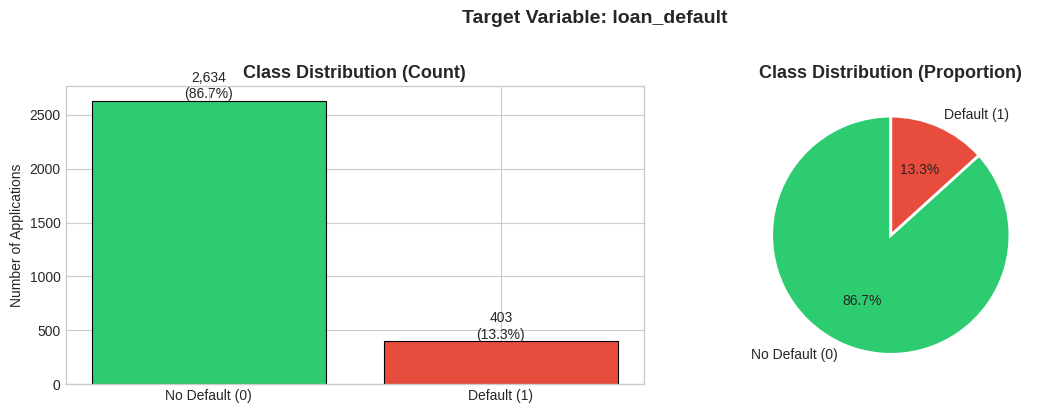

Saved: 01_class_distribution.png


In [8]:
# ── CELL 8: Class distribution ─────────────────────────────────────────────────
target = 'loan_default'

value_counts = df[target].value_counts().sort_index()
default_rate = df[target].mean()
n_defaults   = df[target].sum()
n_total      = len(df)

print('=' * 55)
print('CLASS DISTRIBUTION')
print('=' * 55)
print(f'  Total applications  : {n_total:,}')
print(f'  Non-defaults (0)    : {value_counts[0]:,}  ({value_counts[0]/n_total:.1%})')
print(f'  Defaults (1)        : {value_counts[1]:,}  ({value_counts[1]/n_total:.1%})')
print(f'  Default rate        : {default_rate:.4f}  ({default_rate:.2%})')
print(f'  Imbalance ratio     : {value_counts[0]/value_counts[1]:.1f}:1 (non-default:default)')
print()
print('IMPLICATION: A naive model predicting always "no default" achieves')
print(f'  {1 - default_rate:.2%} accuracy while catching 0% of actual defaults.')
print('  → Accuracy is USELESS. We will use AUC-ROC, Gini, Recall, PR-AUC.')
print(f'  → scale_pos_weight for XGBoost = {value_counts[0]/value_counts[1]:.2f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
labels = ['No Default (0)', 'Default (1)']

axes[0].bar(labels, value_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Applications')
for i, v in enumerate(value_counts.values):
    axes[0].text(i, v + 20, f'{v:,}\n({v/n_total:.1%})', ha='center', fontsize=10)

axes[1].pie(value_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: loan_default', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: 01_class_distribution.png')

---
## EDA Question 2: What is the Missing Data Pattern?

**Decision rule we apply:**
- **> 50% missing** → consider dropping the column (cannot reliably impute majority of values)
- **10–50% missing** → strategy depends on the column (group-based imputation, flag creation)
- **< 10% missing** → median/mode imputation is acceptable

**Key insight:** Absence of data is itself information. For `credit_bureau_score`, missing means the applicant has no bureau file — not that their score is zero. We must preserve this signal.

In [9]:
# ── CELL 9: Missing data analysis ─────────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct':   (df.isnull().sum() / len(df) * 100).round(2),
    'dtype':         df.dtypes,
    'non_null_count': df.notnull().sum()
}).sort_values('missing_pct', ascending=False)

missing_cols = missing[missing['missing_pct'] > 0]
print('MISSING DATA SUMMARY')
print('=' * 60)
print(missing_cols.to_string())
print()
print(f'Columns with NO missing data: {(missing["missing_pct"] == 0).sum()}')
print(f'Columns with missing data:    {(missing["missing_pct"] > 0).sum()}')

MISSING DATA SUMMARY
                              missing_count  missing_pct    dtype  non_null_count
credit_bureau_score                    1967      64.7700  float64            1070
gra_tin                                1031      33.9500   object            2006
previous_default                        604      19.8900   object            2433
monthly_momo_volume_ghs                 454      14.9500  float64            2583
collateral_value_ghs                    389      12.8100  float64            2648
collateral_type                         367      12.0800   object            2670
avg_monthly_bank_balance_ghs            309      10.1700  float64            2728
annual_revenue_ghs                       87       2.8600   object            2950
business_name                             4       0.1300   object            3033

Columns with NO missing data: 20
Columns with missing data:    9


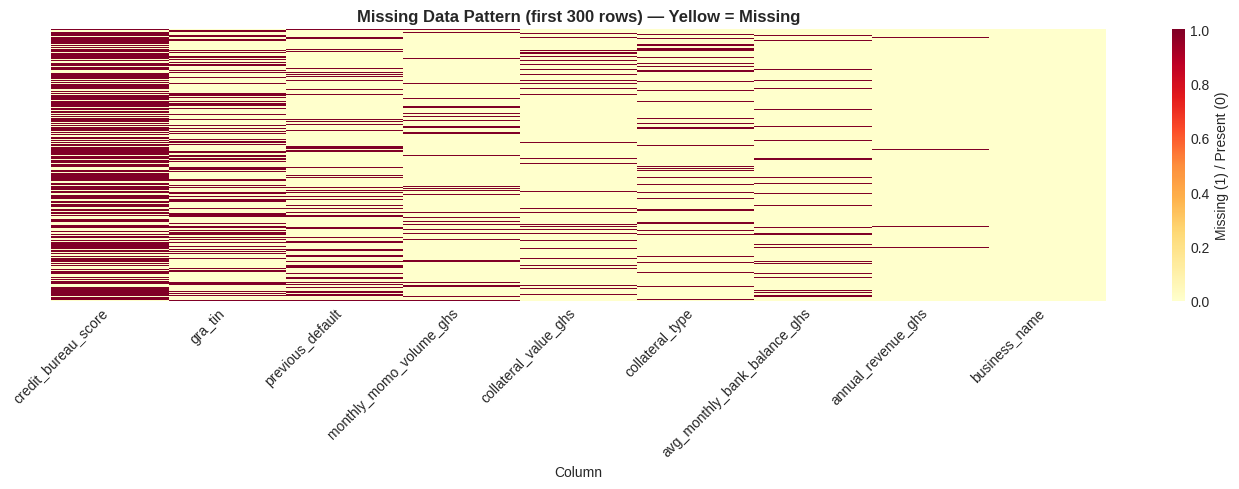

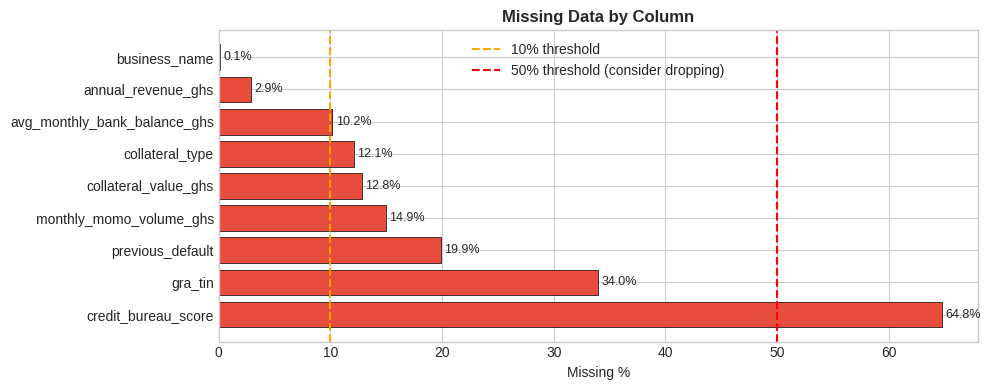

In [10]:
# ── CELL 10: Missing data heatmap ──────────────────────────────────────────────
# Visual pattern of missingness — is it random or clustered?
# If rows missing credit_bureau_score ALSO tend to miss monthly_momo_volume,
# that suggests a systematic pattern (e.g., informal sector applicants)

missing_only = missing_cols[missing_cols['missing_pct'] > 0].index.tolist()

if missing_only:
    fig, ax = plt.subplots(figsize=(14, 5))
    # Show first 200 rows for visual inspection
    sns.heatmap(df[missing_only].head(300).isnull(),
                yticklabels=False, cbar=True,
                cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Missing (1) / Present (0)'})
    ax.set_title('Missing Data Pattern (first 300 rows) — Yellow = Missing',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}/02_missing_data_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bar chart of missing %
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(missing_cols.index, missing_cols['missing_pct'], color='#e74c3c', edgecolor='black', linewidth=0.5)
    ax.axvline(10, color='orange', linestyle='--', linewidth=1.5, label='10% threshold')
    ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% threshold (consider dropping)')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Data by Column', fontsize=12, fontweight='bold')
    ax.legend()
    for bar, pct in zip(bars, missing_cols['missing_pct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}/02b_missing_data_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
# ── CELL 11: Missing data by default status ────────────────────────────────────
# Key question: Are missing values MORE common among defaulters?
# If yes, missingness is not random — it carries predictive signal.
# This justifies creating binary "has_X" flags.

print('MISSING DATA RATE BY DEFAULT STATUS')
print('(Are defaulters more likely to have missing data?)')
print('=' * 55)
for col in missing_only:
    miss_rate_0 = df[df[target]==0][col].isnull().mean()
    miss_rate_1 = df[df[target]==1][col].isnull().mean()
    diff = miss_rate_1 - miss_rate_0
    flag = '  ← SIGNAL' if abs(diff) > 0.05 else ''
    print(f'  {col:<35} Non-default: {miss_rate_0:.1%}  |  Default: {miss_rate_1:.1%}  |  Δ={diff:+.1%}{flag}')

MISSING DATA RATE BY DEFAULT STATUS
(Are defaulters more likely to have missing data?)
  credit_bureau_score                 Non-default: 64.9%  |  Default: 64.0%  |  Δ=-0.9%
  gra_tin                             Non-default: 34.5%  |  Default: 30.5%  |  Δ=-4.0%
  previous_default                    Non-default: 20.7%  |  Default: 14.9%  |  Δ=-5.8%  ← SIGNAL
  monthly_momo_volume_ghs             Non-default: 14.6%  |  Default: 17.1%  |  Δ=+2.5%
  collateral_value_ghs                Non-default: 12.7%  |  Default: 13.6%  |  Δ=+1.0%
  collateral_type                     Non-default: 11.8%  |  Default: 13.6%  |  Δ=+1.8%
  avg_monthly_bank_balance_ghs        Non-default: 10.5%  |  Default: 8.2%  |  Δ=-2.3%
  annual_revenue_ghs                  Non-default: 3.0%  |  Default: 2.2%  |  Δ=-0.7%
  business_name                       Non-default: 0.2%  |  Default: 0.0%  |  Δ=-0.2%


---
## EDA Question 3: What Do Numeric Feature Distributions Look Like?

**Why this matters:**
- Logistic Regression assumes a linear relationship between features and log-odds of the outcome
- Financial data is almost always **right-skewed** (log-normal): a few businesses have enormous revenues
- A GHS 5M revenue is not 1000× more meaningful than GHS 5K revenue — the relationship is logarithmic
- **If we detect heavy right skew → we apply `log1p` transformation for Logistic Regression**
- XGBoost (tree-based) uses rank-based splits → scale-invariant → no transformation needed

In [12]:
# ── CELL 12: Numeric feature distributions ────────────────────────────────────
NUMERIC_COLS = [
    'years_in_operation', 'owner_age', 'num_employees',
    'annual_revenue_ghs', 'monthly_momo_volume_ghs',
    'avg_monthly_bank_balance_ghs', 'bank_account_tenure_months',
    'loan_amount_requested_ghs', 'collateral_value_ghs',
    'credit_bureau_score', 'previous_loan_count', 'days_past_due_current'
]

# Make revenue/financial columns numeric first (some have "GHS " prefix)
for col in NUMERIC_COLS:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(r'[GHS$,\s]', '', regex=True).str.strip(),
            errors='coerce'
        )

# Descriptive statistics
desc = df[NUMERIC_COLS].describe().T
desc['skewness'] = df[NUMERIC_COLS].skew()
desc['kurtosis'] = df[NUMERIC_COLS].kurtosis()
print('NUMERIC FEATURE DESCRIPTIVE STATISTICS')
print('(skewness > 1 → right-skewed → consider log transformation for Logistic Regression)')
print()
print(desc[['mean', 'std', 'min', '50%', 'max', 'skewness']].to_string())

NUMERIC FEATURE DESCRIPTIVE STATISTICS
(skewness > 1 → right-skewed → consider log transformation for Logistic Regression)

                                    mean         std      min        50%          max  skewness
years_in_operation                5.2956      8.7296  -2.0000     3.5000     200.0000   14.2832
owner_age                        43.5565     47.2430  -5.0000    41.0000     999.0000   19.1046
num_employees                    11.9730     16.9741   1.0000     7.0000     251.0000    4.7160
annual_revenue_ghs           155474.4602 368545.2916 102.6100 53475.3750 9498575.1600   10.8196
monthly_momo_volume_ghs        6533.9756  11667.6419  55.4000  3084.0000  182534.1500    6.6668
avg_monthly_bank_balance_ghs  27144.7145 138322.2231  34.7200  8370.1250 6706758.9600   41.6726
bank_account_tenure_months       36.2463     36.3225   0.0000    25.0000     240.0000    1.8752
loan_amount_requested_ghs     35176.9248  43715.7393 569.5900 21418.6200  815331.5000    5.6913
collateral_v

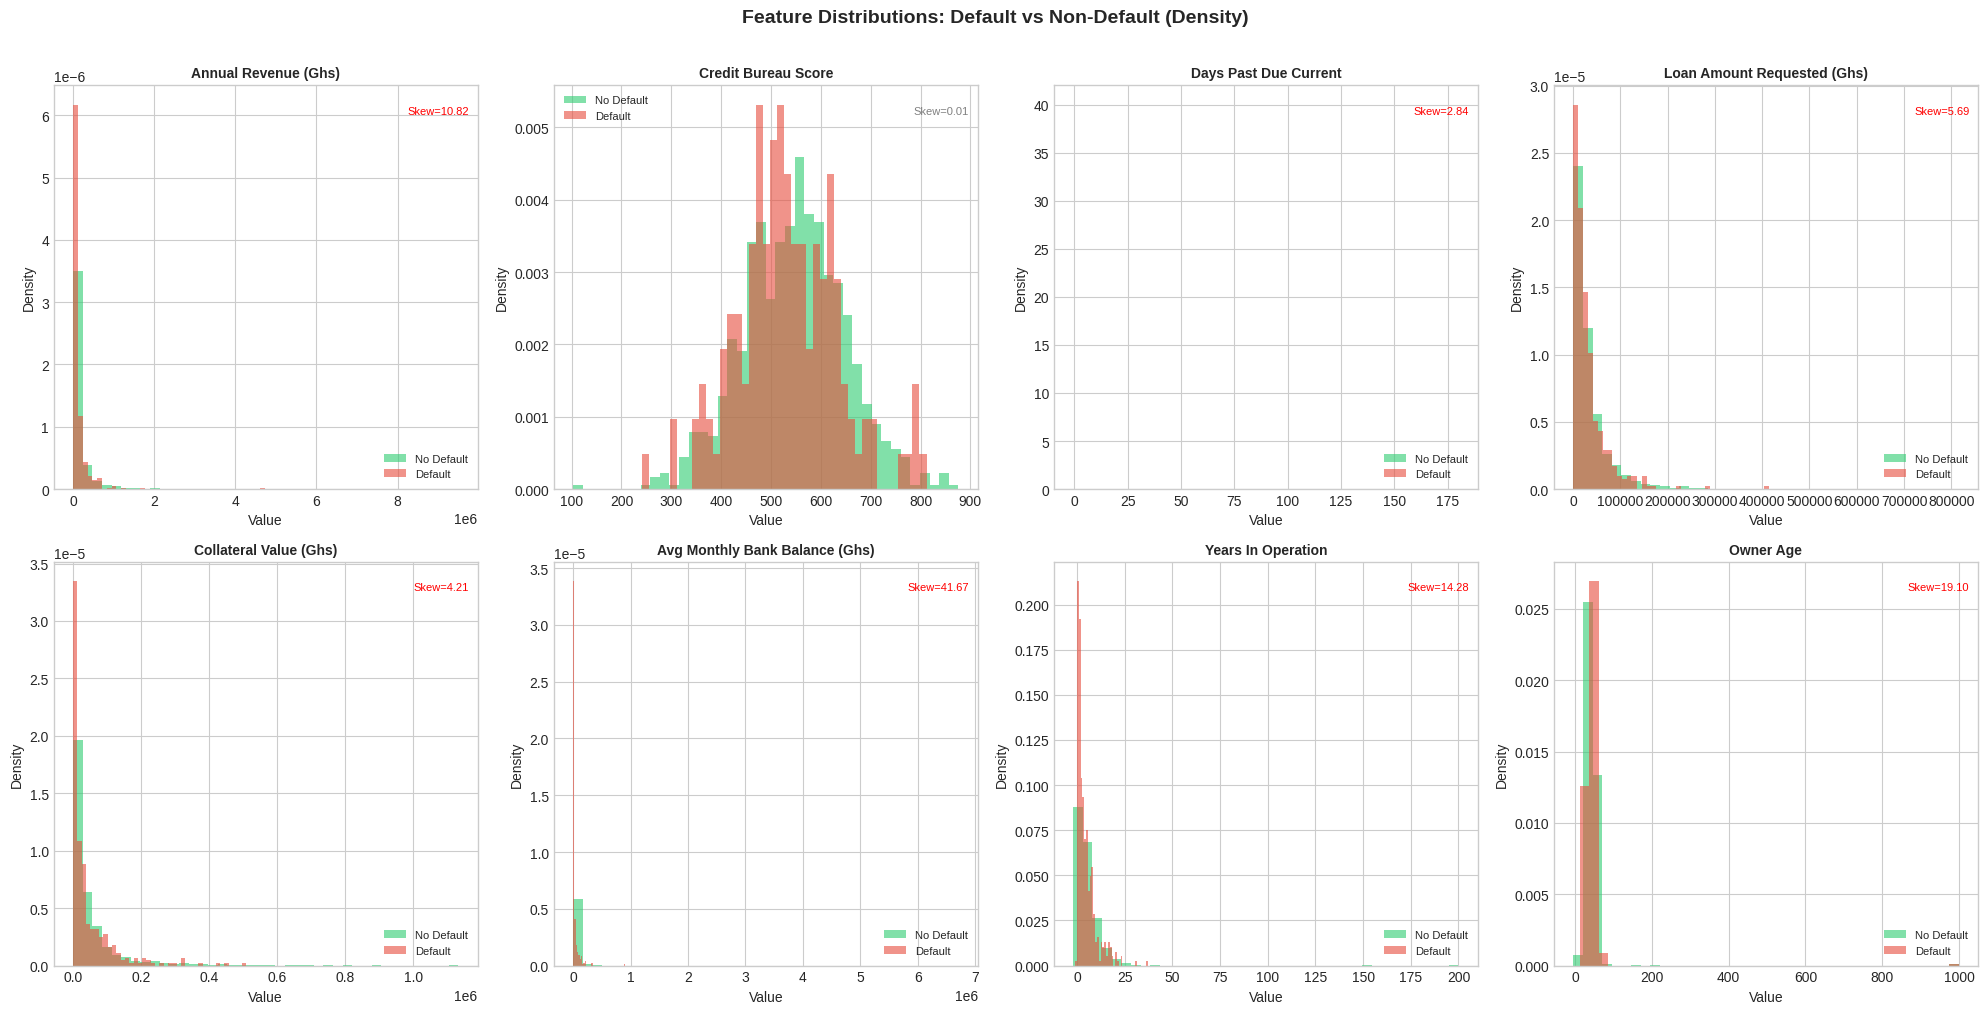

Saved: 03_feature_distributions.png


In [13]:
# ── CELL 13: Distribution plots (raw vs defaulters/non-defaulters) ────────────
# Plotting the distribution SPLIT by loan_default reveals which features
# best separate the two classes — visually validating feature importance.

PLOT_COLS = [
    'annual_revenue_ghs', 'credit_bureau_score', 'days_past_due_current',
    'loan_amount_requested_ghs', 'collateral_value_ghs',
    'avg_monthly_bank_balance_ghs', 'years_in_operation', 'owner_age'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(PLOT_COLS):
    ax = axes[i]
    data_0 = df[df[target]==0][col].dropna()
    data_1 = df[df[target]==1][col].dropna()

    ax.hist(data_0, bins=40, alpha=0.6, label='No Default', color='#2ecc71', density=True)
    ax.hist(data_1, bins=40, alpha=0.6, label='Default',    color='#e74c3c', density=True)
    ax.set_title(col.replace('_ghs', ' (GHS)').replace('_', ' ').title(),
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    skew = df[col].skew()
    ax.annotate(f'Skew={skew:.2f}', xy=(0.98, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                color='red' if abs(skew) > 1 else 'gray')

plt.suptitle('Feature Distributions: Default vs Non-Default (Density)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_feature_distributions.png')

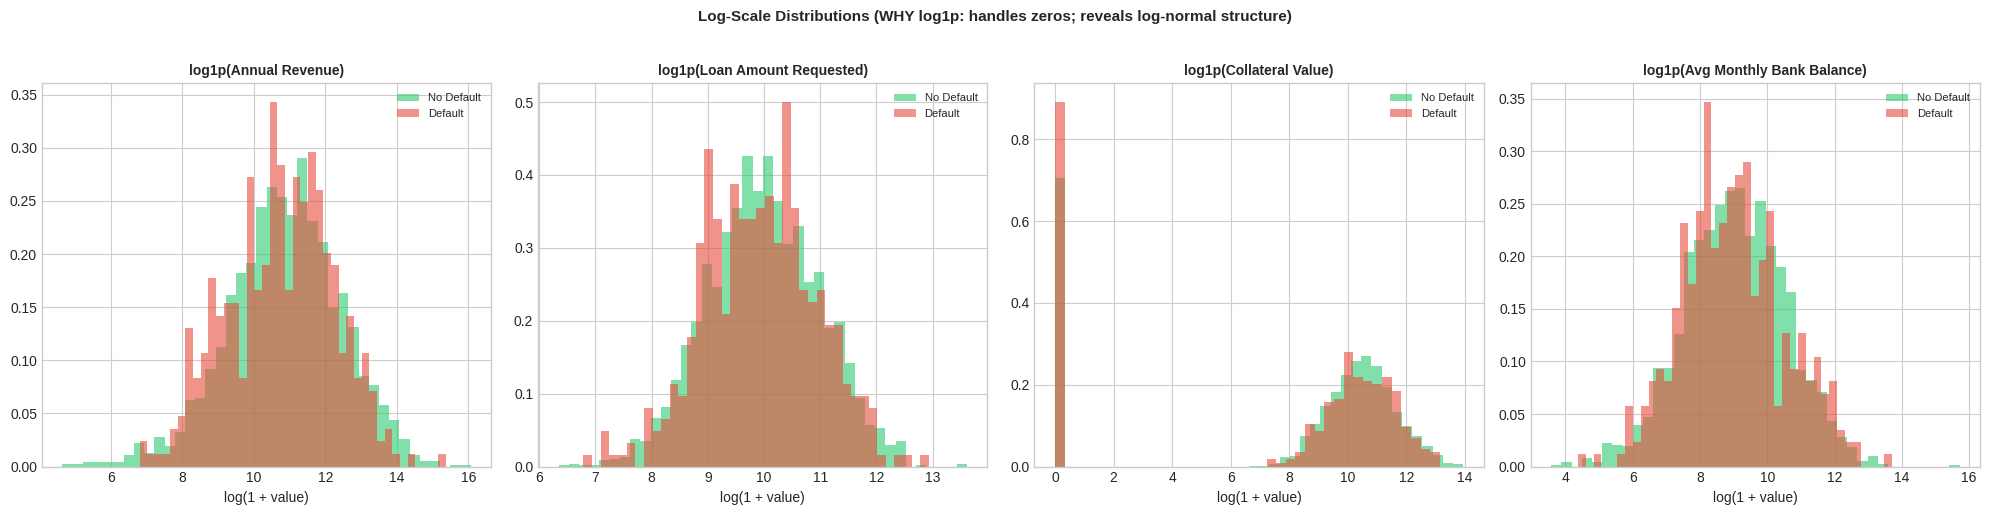

In [14]:
# ── CELL 14: Log-scale distributions for highly skewed financial features ──────
# WHY log scale: Financial distributions are often log-normal.
# On log scale, a good model should show clear separation between
# defaulters and non-defaulters.

SKEWED_COLS = ['annual_revenue_ghs', 'loan_amount_requested_ghs',
               'collateral_value_ghs', 'avg_monthly_bank_balance_ghs']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(SKEWED_COLS):
    ax = axes[i]
    data_0 = np.log1p(df[df[target]==0][col].dropna().clip(lower=0))
    data_1 = np.log1p(df[df[target]==1][col].dropna().clip(lower=0))

    ax.hist(data_0, bins=40, alpha=0.6, label='No Default', color='#2ecc71', density=True)
    ax.hist(data_1, bins=40, alpha=0.6, label='Default',    color='#e74c3c', density=True)
    ax.set_title(f'log1p({col.split("_ghs")[0].replace("_"," ").title()})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('log(1 + value)')
    ax.legend(fontsize=8)

plt.suptitle('Log-Scale Distributions (WHY log1p: handles zeros; reveals log-normal structure)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/03b_log_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA Question 4: Default Rate by Categorical Groups (Fairness Baseline)

**This section serves TWO purposes:**

1. **Feature validation:** If default rate varies significantly across sectors, region is a legitimate predictor. If it barely varies, the feature may not be worth including.

2. **Fairness baseline (CRITICAL):** We must document approval/default rates by protected group *before* the model runs. This is the baseline that proves whether any disparities in model decisions existed in the raw data or were introduced by the model.

**The key ethical question about ethnic_group:** If Ethnic Group A has a 25% default rate and Group B has 8%, we need to ask WHY. If the gap is explained by wealth differences (caused by historical discrimination), including ethnicity perpetuates that discrimination. We document the gap and then EXCLUDE ethnicity from the model.

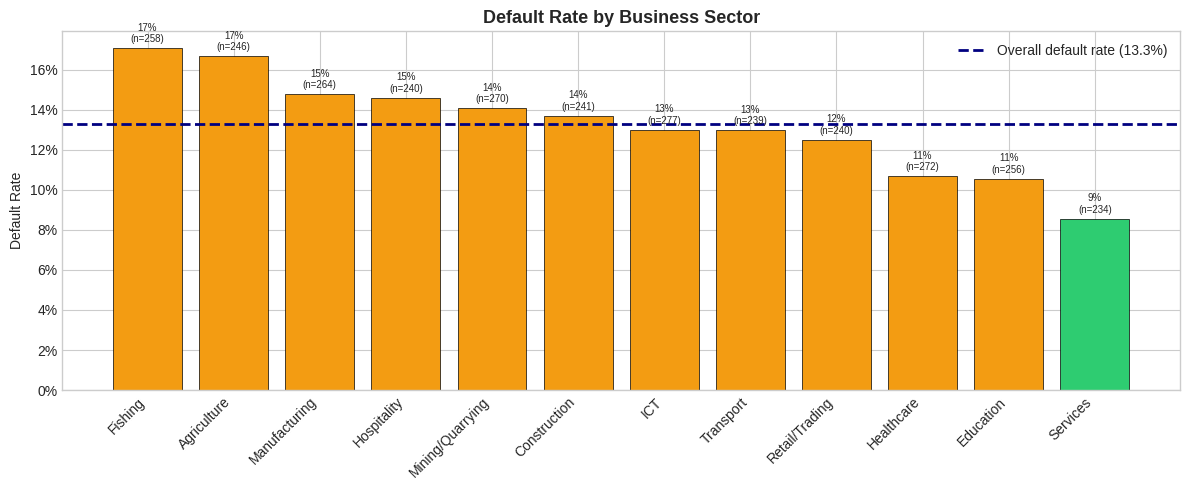

          sector  default_rate  count
         Fishing        0.1705    258
     Agriculture        0.1667    246
   Manufacturing        0.1477    264
     Hospitality        0.1458    240
Mining/Quarrying        0.1407    270
    Construction        0.1369    241
             ICT        0.1300    277
       Transport        0.1297    239
  Retail/Trading        0.1250    240
      Healthcare        0.1066    272
       Education        0.1055    256
        Services        0.0855    234


In [15]:
# ── CELL 15: Default rate by business sector ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

sector_stats = (
    df.groupby('sector')[target]
    .agg(default_rate='mean', count='count')
    .sort_values('default_rate', ascending=False)
    .reset_index()
)

colors = ['#e74c3c' if r > 0.2 else '#f39c12' if r > 0.1 else '#2ecc71'
          for r in sector_stats['default_rate']]

bars = ax.bar(sector_stats['sector'], sector_stats['default_rate'],
              color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(df[target].mean(), color='navy', linestyle='--', linewidth=2,
           label=f'Overall default rate ({df[target].mean():.1%})')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by Business Sector', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.xticks(rotation=45, ha='right')
ax.legend()
for bar, row in zip(bars, sector_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{row.default_rate:.0%}\n(n={row.count})', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/04_default_rate_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

print(sector_stats.to_string(index=False))

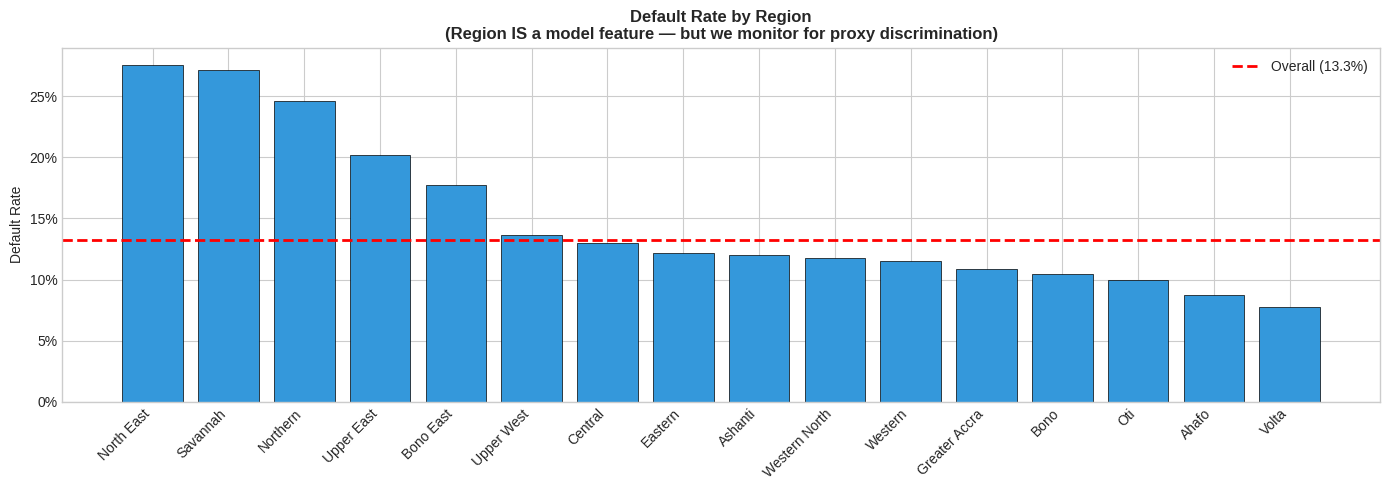

In [16]:
# ── CELL 16: Default rate by region ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

region_stats = (
    df.groupby('region')[target]
    .agg(default_rate='mean', count='count')
    .sort_values('default_rate', ascending=False)
    .reset_index()
)

ax.bar(region_stats['region'], region_stats['default_rate'],
       color='#3498db', edgecolor='black', linewidth=0.5)
ax.axhline(df[target].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Overall ({df[target].mean():.1%})')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by Region\n(Region IS a model feature — but we monitor for proxy discrimination)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/05_default_rate_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

FAIRNESS BASELINE: DEFAULT RATE BY PROTECTED ATTRIBUTE
(These attributes will NOT be model features — fairness monitor only)

OWNER_GENDER:
owner_gender  default_rate  count
        Male        0.1424    899
           M        0.1395    301
      female        0.1381    514
      Female        0.1322    726
        male        0.1279    297
           F        0.0933    300

ETHNIC_GROUP:
ethnic_group  default_rate  count
       Gurma        0.2462    130
       Mande        0.2414     29
Mole-Dagbani        0.1578    450
        Guan        0.1446    166
  Ga-Adangbe        0.1283    460
       Grusi        0.1237     97
        Akan        0.1223   1276
         Ewe        0.0979    429

DISABILITY_STATUS:
disability_status  default_rate  count
              Yes        0.1437    167
               No        0.1321   2870


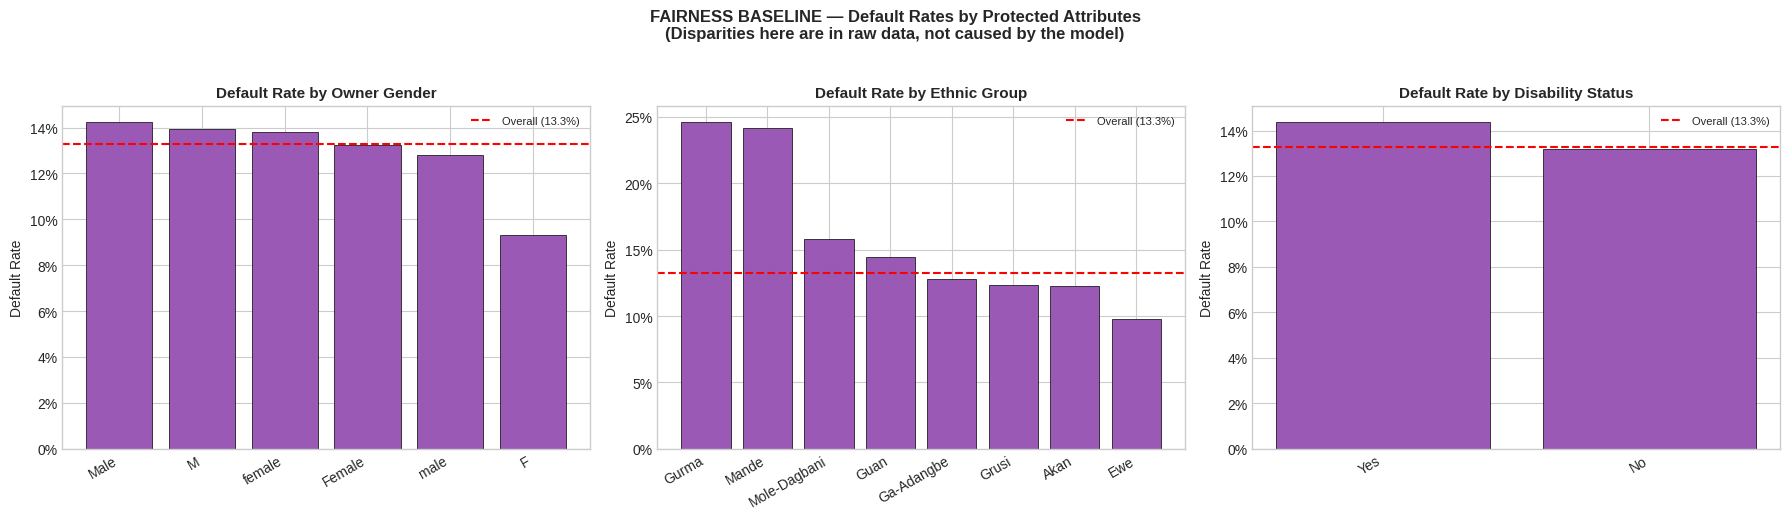

In [17]:
# ── CELL 17: FAIRNESS BASELINE — Default rate by protected attributes ──────────
# This is the pre-model fairness baseline.
# Document this carefully: it shows what disparities ALREADY EXIST in the raw data
# before any model has been applied.

PROTECTED_ATTRS = ['owner_gender', 'ethnic_group', 'disability_status']

print('=' * 65)
print('FAIRNESS BASELINE: DEFAULT RATE BY PROTECTED ATTRIBUTE')
print('(These attributes will NOT be model features — fairness monitor only)')
print('=' * 65)

fairness_baselines = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, attr in zip(axes, PROTECTED_ATTRS):
    stats_df = (
        df.groupby(attr)[target]
        .agg(default_rate='mean', count='count')
        .sort_values('default_rate', ascending=False)
        .reset_index()
    )
    fairness_baselines[attr] = stats_df

    ax.bar(stats_df[attr].astype(str), stats_df['default_rate'],
           color='#9b59b6', edgecolor='black', linewidth=0.5)
    ax.axhline(df[target].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({df[target].mean():.1%})')
    ax.set_title(f'Default Rate by {attr.replace("_", " ").title()}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Default Rate')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8)

    print(f'\n{attr.upper()}:')
    print(stats_df.to_string(index=False))

plt.suptitle('FAIRNESS BASELINE — Default Rates by Protected Attributes\n'
             '(Disparities here are in raw data, not caused by the model)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/06_fairness_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA Question 5: What is the Correlation With the Target?

**Why point-biserial correlation (not Pearson):**
Point-biserial correlation is the correct measure for continuous vs. binary variables. Pearson correlation assumes continuous variables on both sides; point-biserial is mathematically derived from the t-test and handles binary targets correctly.

**Formula:** Point-biserial correlation is equivalent to Pearson when applied to a binary variable.

POINT-BISERIAL CORRELATION WITH loan_default
(Positive = feature increases default probability)
(Negative = feature decreases default probability)
                             correlation p_value     n significant
days_past_due_current             0.9098  0.0000  3037        True
credit_bureau_score              -0.0471  0.1236  1070       False
years_in_operation               -0.0308  0.0896  3037       False
annual_revenue_ghs               -0.0306  0.0965  2950       False
monthly_momo_volume_ghs          -0.0288  0.1436  2583       False
collateral_value_ghs             -0.0258  0.1848  2648       False
previous_loan_count               0.0252  0.1656  3037       False
loan_amount_requested_ghs        -0.0179  0.3246  3037       False
num_employees                    -0.0085  0.6408  3037       False
avg_monthly_bank_balance_ghs     -0.0031  0.8713  2728       False
bank_account_tenure_months       -0.0013  0.9410  3037       False
owner_age                         0.0002  0.9903 

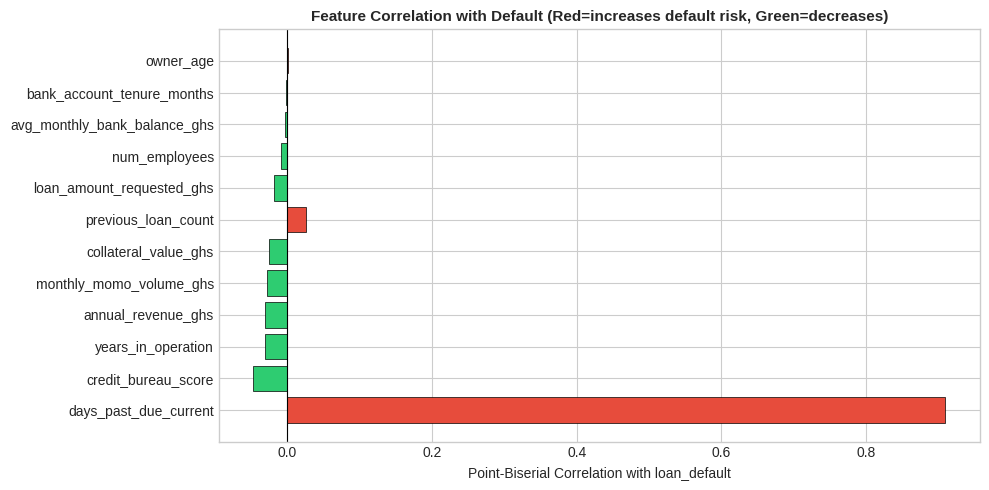

In [18]:
# ── CELL 18: Point-biserial correlation with target ────────────────────────────
correlations = {}
for col in NUMERIC_COLS:
    clean = df[[col, target]].dropna()
    if len(clean) > 30 and clean[col].std() > 0:
        corr, pval = pointbiserialr(clean[col], clean[target])
        correlations[col] = {
            'correlation': corr,
            'p_value':     pval,
            'n':           len(clean),
            'significant': pval < 0.05
        }

corr_df = (
    pd.DataFrame(correlations).T
    .sort_values('correlation', key=abs, ascending=False)
)

print('POINT-BISERIAL CORRELATION WITH loan_default')
print('(Positive = feature increases default probability)')
print('(Negative = feature decreases default probability)')
print('=' * 65)
print(corr_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in corr_df['correlation'].astype(float)]
ax.barh(corr_df.index, corr_df['correlation'].astype(float),
        color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with loan_default')
ax.set_title('Feature Correlation with Default (Red=increases default risk, Green=decreases)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/07_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA Question 6: Multicollinearity Check (VIF)

**Why VIF (Variance Inflation Factor):**
- Multicollinearity means two features carry nearly the same information
- For **Logistic Regression**: highly correlated features cause unstable coefficients (large standard errors) — makes the model hard to interpret and unreliable
- For **XGBoost**: less critical (tree splits on individual features), but still worth documenting
- **VIF > 10**: problematic — consider dropping one feature or combining them
- **VIF = 1**: no correlation with any other feature (ideal)

**Formula:** `VIF_i = 1 / (1 - R²_i)` where R²_i is the R² from regressing feature i on all other features.

In [19]:
# ── CELL 19: Variance Inflation Factor ────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only numeric columns with sufficient non-null data
vif_cols = [c for c in NUMERIC_COLS if df[c].isnull().mean() < 0.5 and c != target]
vif_data = df[vif_cols].dropna()

vif_results = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(vif_cols))
    ]
}).sort_values('VIF', ascending=False)

vif_results['concern_level'] = vif_results['VIF'].apply(
    lambda v: 'HIGH (>10) — investigate' if v > 10
    else ('MODERATE (5-10)' if v > 5 else 'LOW (<5) — OK')
)

print('VARIANCE INFLATION FACTOR (VIF) — Multicollinearity Check')
print('(Critical for Logistic Regression; less so for XGBoost)')
print('=' * 60)
print(vif_results.to_string(index=False))

VARIANCE INFLATION FACTOR (VIF) — Multicollinearity Check
(Critical for Logistic Regression; less so for XGBoost)
                     feature    VIF concern_level
         previous_loan_count 2.0156 LOW (<5) — OK
  bank_account_tenure_months 1.7780 LOW (<5) — OK
                   owner_age 1.5798 LOW (<5) — OK
   loan_amount_requested_ghs 1.4546 LOW (<5) — OK
               num_employees 1.4049 LOW (<5) — OK
          years_in_operation 1.2701 LOW (<5) — OK
        collateral_value_ghs 1.2516 LOW (<5) — OK
     monthly_momo_volume_ghs 1.2489 LOW (<5) — OK
          annual_revenue_ghs 1.1326 LOW (<5) — OK
       days_past_due_current 1.1061 LOW (<5) — OK
avg_monthly_bank_balance_ghs 1.0327 LOW (<5) — OK


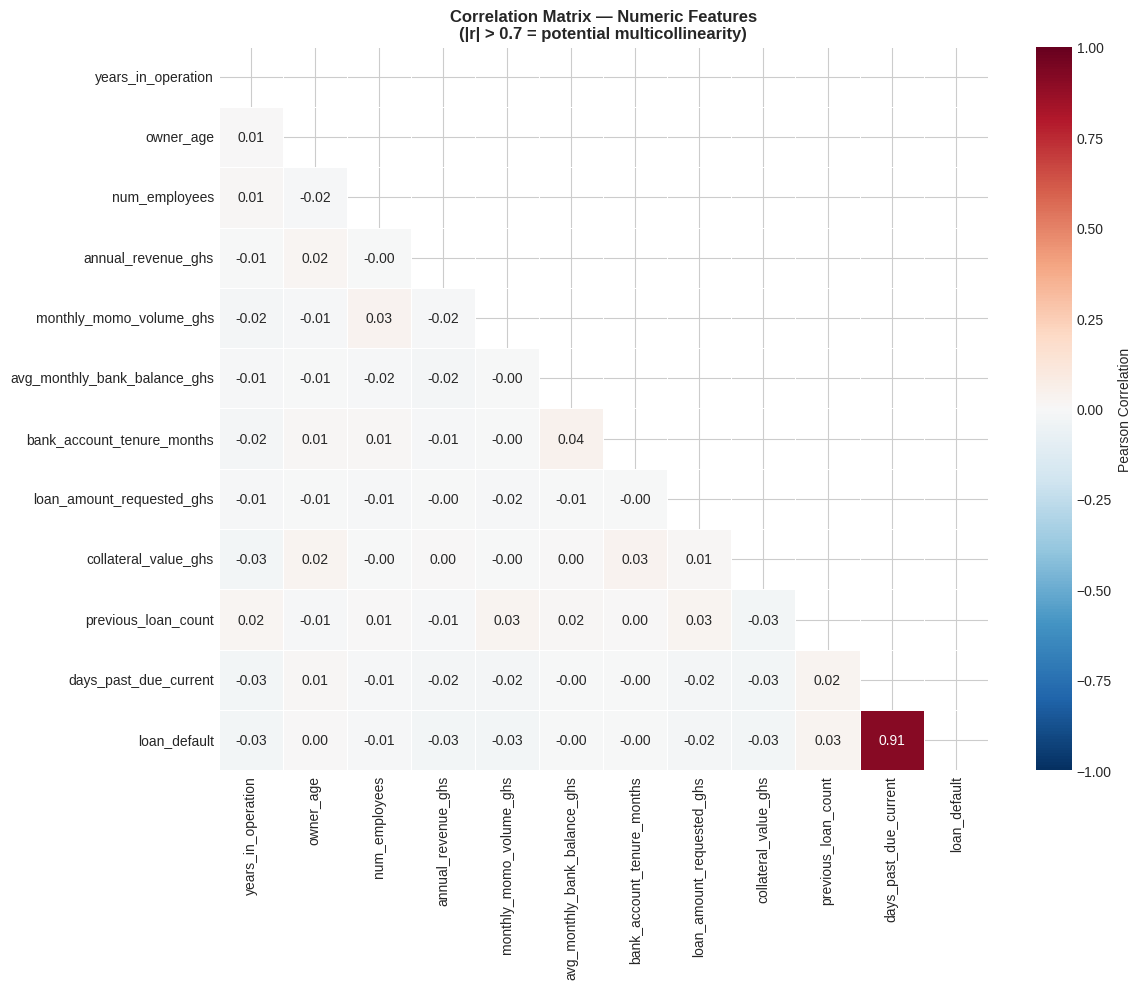

In [20]:
# ── CELL 20: Correlation heatmap among numeric features ────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[vif_cols + [target]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', linewidths=0.5,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Correlation Matrix — Numeric Features\n(|r| > 0.7 = potential multicollinearity)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Additional EDA: Categorical Feature Analysis

In [21]:
# ── CELL 21: Categorical feature value counts ──────────────────────────────────
CAT_COLS = ['sector', 'region', 'loan_purpose', 'collateral_type',
            'previous_default', 'has_momo_account', 'rm_recommendation',
            'internal_risk_grade', 'owner_gender', 'ethnic_group']

for col in CAT_COLS:
    print(f'\n{col.upper()}:')
    counts = df[col].value_counts(dropna=False)
    pcts   = df[col].value_counts(dropna=False, normalize=True)
    result = pd.DataFrame({'count': counts, 'pct': pcts})
    result['pct'] = result['pct'].map('{:.1%}'.format)
    print(result.to_string())


SECTOR:
                  count   pct
sector                       
ICT                 277  9.1%
Healthcare          272  9.0%
Mining/Quarrying    270  8.9%
Manufacturing       264  8.7%
Fishing             258  8.5%
Education           256  8.4%
Agriculture         246  8.1%
Construction        241  7.9%
Hospitality         240  7.9%
Retail/Trading      240  7.9%
Transport           239  7.9%
Services            234  7.7%

REGION:
               count    pct
region                     
Greater Accra    754  24.8%
Ashanti          615  20.3%
Western          243   8.0%
Central          208   6.8%
Northern         199   6.6%
Eastern          197   6.5%
Volta            154   5.1%
Bono             124   4.1%
Bono East         96   3.2%
Upper East        89   2.9%
Western North     68   2.2%
Upper West        66   2.2%
Savannah          59   1.9%
North East        58   1.9%
Ahafo             57   1.9%
Oti               50   1.6%

LOAN_PURPOSE:
                    count    pct
loan_purpo

In [22]:
# ── CELL 22: has_momo_account unique values — shows the cleaning needed ────────
print('has_momo_account UNIQUE VALUES (raw):')
print('This demonstrates WHY standardization is needed.')
print()
print(df['has_momo_account'].value_counts(dropna=False).to_string())
print()
print('annual_revenue_ghs non-numeric sample (shows currency format issues):')
mask = df['annual_revenue_ghs'].isnull()
print(df_raw['annual_revenue_ghs'][mask].head(10).to_list())

has_momo_account UNIQUE VALUES (raw):
This demonstrates WHY standardization is needed.

has_momo_account
Yes     845
No      457
yes     338
Y       321
1       301
0       291
TRUE    177
N       159
no      148

annual_revenue_ghs non-numeric sample (shows currency format issues):
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [23]:
# ── CELL 23: owner_age outlier check ──────────────────────────────────────────
print('OWNER AGE DISTRIBUTION (raw):')
print(df['owner_age'].describe())
print()
invalid_ages = df[df['owner_age'] < 18][['application_id', 'business_name', 'owner_age', target]]
if len(invalid_ages) > 0:
    print(f'\nINVALID AGES (< 18): {len(invalid_ages)} records')
    print(invalid_ages.to_string())
    print('\nDecision: Set these to NaN → impute with median in preprocessing.')
    print('Reason: No legitimate SME owner in Ghana can be under 18 legally.')
else:
    print('No invalid ages detected.')

OWNER AGE DISTRIBUTION (raw):
count   3037.0000
mean      43.5565
std       47.2430
min       -5.0000
25%       34.0000
50%       41.0000
75%       48.0000
max      999.0000
Name: owner_age, dtype: float64


INVALID AGES (< 18): 30 records
      application_id                      business_name  owner_age  loan_default
52    SBG-2025-01657                    Ho ElectricalGH         14             0
56    SBG-2025-02501             Madina DigitalVentures         15             0
289   SBG-2025-02064                  Grace Foods LtdGH         17             0
323   SBG-2025-00681                    Kwaku TradingCo         17             0
328   SBG-2025-01796                   Dzorwulu Digital         15             0
518   SBG-2025-02286                 Dansoman TradingGH         12             0
688   SBG-2025-00598                Kasoa Trading HubGH         12             0
783   SBG-2025-02430       Nkrumah Circle ElectronicsCo         10             0
832   SBG-2025-02489           

---
## EDA Summary

This cell documents the key findings that will drive all subsequent modeling decisions.

In [24]:
# ── CELL 24: EDA Summary — decisions driven by findings ───────────────────────
print('=' * 70)
print('EDA SUMMARY — KEY FINDINGS AND MODELING DECISIONS')
print('=' * 70)

print(f"""
FINDING 1: CLASS IMBALANCE
  Default rate       = {default_rate:.2%}
  Imbalance ratio    = {value_counts[0]/value_counts[1]:.1f}:1
  Decision           : Use class_weight='balanced' for Logistic Regression
                       Use scale_pos_weight={value_counts[0]/value_counts[1]:.2f} for XGBoost
                       Evaluate with AUC-ROC, Gini, Recall — NOT accuracy

FINDING 2: MISSING DATA
  See missing_cols table above
  Decision           : Create binary flags for credit_bureau_score and
                       monthly_momo_volume before imputing values
                       previous_default → has_previous_loan_history + prev_default_clean

FINDING 3: SKEWNESS
  Financial columns (revenue, balance, loan amount, collateral) are
  heavily right-skewed (skewness > 1)
  Decision           : Apply log1p transformation for Logistic Regression pipeline
                       XGBoost is scale-invariant → no transformation needed

FINDING 4: DATA LEAKAGE (CRITICAL)
  rm_recommendation and internal_risk_grade MUST be dropped.
  These are created AFTER human review — they do not exist for new applications.
  Including them would make the model look perfect but fail in production.

FINDING 5: FAIRNESS BASELINE
  Default rates by protected group are documented above.
  ethnic_group, owner_gender, disability_status are EXCLUDED from the model.
  Region IS included (legitimate economic predictor) but will be monitored.
""")
print('=' * 70)
print('Proceed to notebook 02_preprocessing.ipynb')

EDA SUMMARY — KEY FINDINGS AND MODELING DECISIONS

FINDING 1: CLASS IMBALANCE
  Default rate       = 13.27%
  Imbalance ratio    = 6.5:1
  Decision           : Use class_weight='balanced' for Logistic Regression
                       Use scale_pos_weight=6.54 for XGBoost
                       Evaluate with AUC-ROC, Gini, Recall — NOT accuracy

FINDING 2: MISSING DATA
  See missing_cols table above
  Decision           : Create binary flags for credit_bureau_score and
                       monthly_momo_volume before imputing values
                       previous_default → has_previous_loan_history + prev_default_clean

FINDING 3: SKEWNESS
  Financial columns (revenue, balance, loan amount, collateral) are
  heavily right-skewed (skewness > 1)
  Decision           : Apply log1p transformation for Logistic Regression pipeline
                       XGBoost is scale-invariant → no transformation needed

FINDING 4: DATA LEAKAGE (CRITICAL)
  rm_recommendation and internal_risk_grade MUST

In [25]:
# ── CELL 25: Save EDA-ready dataframe reference ────────────────────────────────
# Save the raw data as-is to data/raw/ (already there if uploaded manually)
# Notebook 02 will load from raw/ and apply all cleaning.
# Here we just confirm shape and print the column list for the next notebook.

print('HANDOFF TO NOTEBOOK 02:')
print(f'  Source file : {RAW_PATH}')
print(f'  Shape       : {df_raw.shape}')
print(f'  Columns     : {list(df_raw.columns)}')
print()
print('EDA complete. All figures saved to:', FIGURES_PATH)

HANDOFF TO NOTEBOOK 02:
  Source file : /content/drive/MyDrive/stanbic_sme_credit/data/raw/ds-sme_loan_applications_stanbic_gh.csv
  Shape       : (3037, 29)
  Columns     : ['application_id', 'business_name', 'sector', 'region', 'ethnic_group', 'years_in_operation', 'owner_gender', 'owner_age', 'disability_status', 'num_employees', 'annual_revenue_ghs', 'monthly_momo_volume_ghs', 'avg_monthly_bank_balance_ghs', 'bank_account_tenure_months', 'has_momo_account', 'gra_tin', 'loan_amount_requested_ghs', 'loan_purpose', 'collateral_type', 'collateral_value_ghs', 'previous_loan_count', 'previous_default', 'credit_bureau_score', 'rm_recommendation', 'internal_risk_grade', 'application_date', 'contact_phone', 'days_past_due_current', 'loan_default']

EDA complete. All figures saved to: /content/drive/MyDrive/stanbic_sme_credit/reports/figures
